# Parcial 1 ·Clasificación de Géneros Musicales usando el Dataset GTZAN


## 1. Importación de librerías y configuración


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix

np.random.seed(42)
torch.manual_seed(42)


datos = Path("Dataset/Data")
salida = Path("resultados")
salida.mkdir(exist_ok=True)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


Usando dispositivo: cuda


## 2. Leer el CSV


In [ ]:
df = pd.read_csv(datos / "features_3_sec.csv")

print("Filas y columnas:", df.shape)
print("Valores vacíos:", df.isna().sum().sum())
df.head()


Filas y columnas: (9990, 60)
Valores vacíos: 0


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


## 3. Ver las clases y su distribución


label
blues        1000
classical     998
country       997
disco         979
hiphop        958
jazz         1000
metal         850
pop           960
reggae        974
rock          988
Name: count, dtype: int64


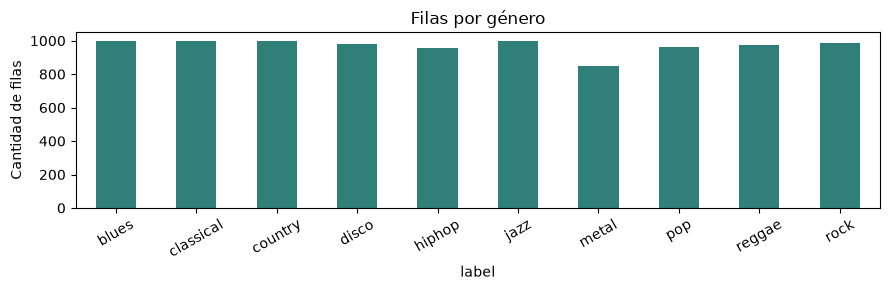

In [16]:
conteo = df["label"].value_counts().sort_index()
print(conteo)

conteo.plot.bar(color="#317f79", figsize=(9, 3))
plt.title("Filas por género")
plt.ylabel("Cantidad de filas")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(salida / "distribucion.png")
plt.show()

## 4. Elegir las entradas y quitar repeticiones



In [ ]:
quitar = ["filename", "length", "label"]
columnas = df.columns.drop(quitar).tolist()


repetidas = df.duplicated(subset=columnas, keep=False)
excluidas = df.loc[repetidas, ["filename", "label"]]
df = df.loc[~repetidas].reset_index(drop=True)

excluidas.to_csv(salida / "filas_excluidas.csv", index=False)
assert np.isfinite(df[columnas].to_numpy()).all()

print("Entradas:", len(columnas))
print("Filas apartadas:", len(excluidas))
print("Filas que usaremos:", len(df))


Entradas: 57
Filas apartadas: 286
Filas que usaremos: 9704


## 5. Procesamiento de Variables y División del Dataset


In [ ]:
clases = sorted(df["label"].unique())
mapa = dict(zip(clases, range(len(clases))))

X = df[columnas].to_numpy(dtype="float32")
y = df["label"].map(mapa).to_numpy()

grupo_cancion = df["filename"].str.replace(r"\.\d+(\.wav)?$", "", regex=True)


separador = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train, test = next(separador.split(X, y, groups=grupo_cancion))

X_train, X_test = X[train], X[test]
y_train, y_test = y[train], y[test]

print("Clases:", mapa)
print("Canciones distintas:", grupo_cancion.nunique())
print("Entrenamiento:", len(train), "filas")
print("Prueba:", len(test), "filas")
assert len(np.unique(y_train)) == len(clases)
assert len(np.unique(y_test)) == len(clases)

canciones_train = set(grupo_cancion.iloc[train])
canciones_test = set(grupo_cancion.iloc[test])
interseccion = canciones_train & canciones_test
assert len(interseccion) == 0, f"¡Fuga de datos! Canciones repetidas: {interseccion}"
print("Canciones que se repiten entre train y test:", len(interseccion))


Clases: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}
Canciones distintas: 972
Entrenamiento: 7756 filas
Prueba: 1948 filas
Canciones que se repiten entre train y test: 0


## 6. Normalizar y convertir a tensores



In [ ]:
media = X_train.mean(axis=0)
desviacion = X_train.std(axis=0)
desviacion[desviacion == 0] = 1

X_train = (X_train - media) / desviacion
X_test = (X_test - media) / desviacion

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print("Forma de X_train:", X_train.shape)


Forma de X_train: torch.Size([7756, 57])


## 7. Arquitectura Neuronal


In [ ]:
modelo = nn.Sequential(
    nn.Linear(len(columnas), 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)


modelo = modelo.to(device)

perdida = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.01)

print(modelo)
print("Modelo en dispositivo:", next(modelo.parameters()).device)


Sequential(
  (0): Linear(in_features=57, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=10, bias=True)
)
Modelo en dispositivo: cuda:0


## 8. Bucle de entrenamiento

In [ ]:
epocas = 150
historial = []
modelo.train()

inputs, labels = X_train.to(device), y_train.to(device)

for epoca in range(epocas):
    optimizador.zero_grad()
    puntajes = modelo(inputs)
    error = perdida(puntajes, labels)
    error.backward()
    optimizador.step()
    historial.append(error.item())

print("Pérdida inicial:", round(historial[0], 4))
print("Pérdida final:", round(historial[-1], 4))


Pérdida inicial: 2.3209
Pérdida final: 0.3642


## 9. Visualización del Descenso del Error

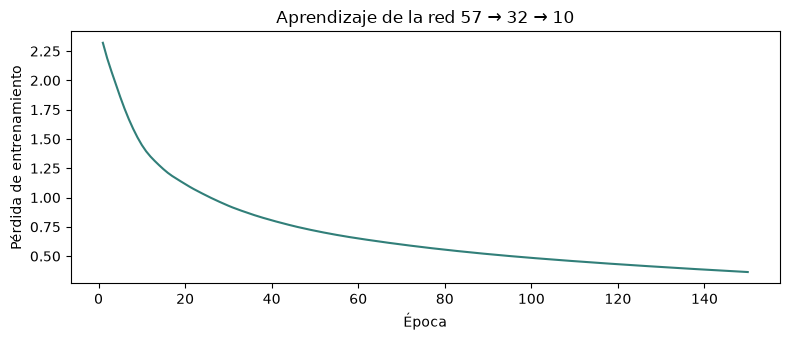

In [11]:
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, epocas + 1), historial, color="#317f79")
plt.xlabel("Época")
plt.ylabel("Pérdida de entrenamiento")
plt.title("Aprendizaje de la red 57 → 32 → 10")
plt.tight_layout()
plt.savefig(salida / "aprendizaje.png")
plt.show()

## 10. Predecir y medir los resultados

In [ ]:
modelo.eval()
with torch.no_grad():
    inputs_test, labels_test = X_test.to(device), y_test.to(device)
    inputs_train, labels_train = X_train.to(device), y_train.to(device)

    puntajes = modelo(inputs_test)
    pred_train = modelo(inputs_train).argmax(dim=1).cpu().numpy()

y_pred = puntajes.argmax(dim=1).cpu().numpy()
y_real = labels_test.cpu().numpy()

accuracy = accuracy_score(y_real, y_pred)
opciones = {"average": "macro", "zero_division": 0}
precision = precision_score(y_real, y_pred, **opciones)
recall = recall_score(y_real, y_pred, **opciones)
f1 = f1_score(y_real, y_pred, **opciones)

metricas = pd.DataFrame({
    "metrica": ["accuracy", "precision", "recall", "f1"],
    "valor": [accuracy, precision, recall, f1]
})

print("Accuracy de prueba:", round(accuracy * 100, 2), "%")
acc_train = accuracy_score(labels_train.cpu().numpy(), pred_train)
print("Accuracy de entrenamiento:", round(acc_train * 100, 2))
metricas


Accuracy de prueba: 68.22 %
Accuracy de entrenamiento: 88.02


,metrica,valor
0,accuracy,0.682238
1,precision,0.681670
2,recall,0.687954
3,f1,0.683838


## 11. Leer la matriz de confusión

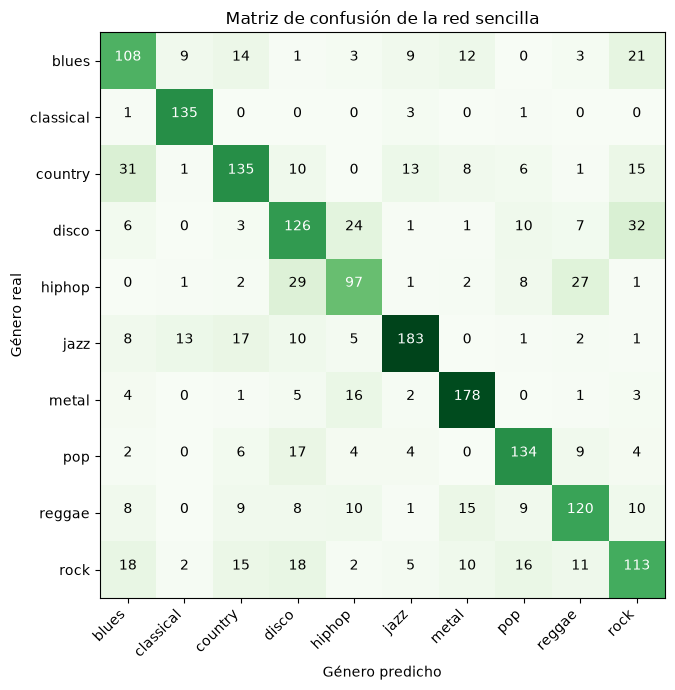

In [13]:
matriz = confusion_matrix(y_real, y_pred, labels=range(10))

plt.figure(figsize=(9, 7))
plt.imshow(matriz, cmap="Greens")
plt.xticks(range(10), clases, rotation=45, ha="right")
plt.yticks(range(10), clases)
plt.xlabel("Género predicho")
plt.ylabel("Género real")
plt.title("Matriz de confusión de la red sencilla")

for fila in range(10):
    for columna in range(10):
        valor = matriz[fila, columna]
        color = "white" if valor > matriz.max() / 2 else "black"
        plt.text(columna, fila, valor, ha="center", color=color)

plt.tight_layout()
plt.savefig(salida / "matriz_confusion.png")
plt.show()

## 12. Ejemplos concretos de predicciones

In [14]:
ejemplos = df.iloc[test][["filename", "label"]].copy()
ejemplos["prediccion"] = np.array(clases)[y_pred]
ejemplos["acierto"] = y_real == y_pred

print("Aciertos:", int(ejemplos["acierto"].sum()))
print("Pistas evaluadas:", len(ejemplos))
ejemplos.head(10)

Aciertos: 1329
Pistas evaluadas: 1948


,filename,label,prediccion,acierto
230,blues.00023.0.wav,blues,blues,True
231,blues.00023.1.wav,blues,blues,True
232,blues.00023.2.wav,blues,jazz,False
233,blues.00023.3.wav,blues,jazz,False
234,blues.00023.4.wav,blues,jazz,False
235,blues.00023.5.wav,blues,jazz,False
236,blues.00023.6.wav,blues,blues,True
237,blues.00023.7.wav,blues,jazz,False
238,blues.00023.8.wav,blues,jazz,False
239,blues.00023.9.wav,blues,blues,True


## 13. Guardado del modelo entrenado

In [15]:
torch.save(modelo.state_dict(), salida / "modelo_mlp.pt")

escala = pd.DataFrame({
    "columna": columnas,
    "media": media,
    "desviacion": desviacion
})
etiquetas = pd.DataFrame({"genero": clases})
curva = pd.DataFrame({"epoca": range(1, epocas + 1)})
curva["perdida"] = historial

division = df[["filename", "label"]].copy()
division["conjunto"] = "train"
division.loc[test, "conjunto"] = "test"

escala.to_csv(salida / "normalizacion.csv", index=False)
etiquetas.to_csv(salida / "clases.csv", index=False)
curva.to_csv(salida / "historial.csv", index=False)
division.to_csv(salida / "particiones.csv", index=False)
metricas.to_csv(salida / "metricas.csv", index=False)
ejemplos.to_csv(salida / "predicciones.csv", index=False)

print("Archivos guardados en:", salida.resolve())

Archivos guardados en: E:\INTELIGENCIA ARTIFICIAL 1\Parcial 1\resultados
